In [4]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [5]:
PD = 0.02
LGD = 0.60
EAD = 100000
rho = 0.2
confidence_level = 0.999

In [6]:
z_pd = norm.ppf(PD)
z_conf = norm.ppf(confidence_level)
capital_per_unit = LGD * norm.cdf((z_pd + np.sqrt(rho) * z_conf)/ np.sqrt(1-rho)) - PD* LGD

capital = capital_per_unit * EAD
print("Capital Per Exposure:", (capital.sum().round(2)))
print("RWA:", (capital * 12.5).sum().round(2))

Capital Per Exposure: 12378.77
RWA: 154734.61


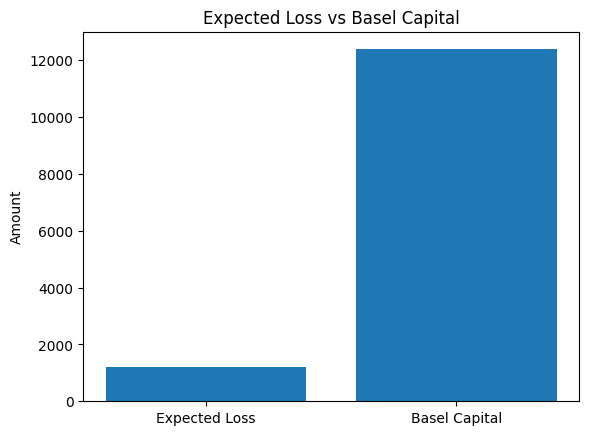

In [7]:
import matplotlib.pyplot as plt

PD = 0.02
LGD = 0.60
EAD = 100000

expected_loss = PD * LGD * EAD
capital = 12378.77

labels = ['Expected Loss', 'Basel Capital']
values = [expected_loss, capital]

plt.bar(labels, values)
plt.title("Expected Loss vs Basel Capital")
plt.ylabel("Amount")
plt.show()

In [8]:
#Portfolio Level Capital

In [9]:
n_loans = 1000

PD = np.random.uniform(0.01,0.05, n_loans)
EAD = np.random.uniform(50000,200000, n_loans)
LGD = 0.6
rho = 0.2

z_conf = norm.ppf(0.999)

capital_list = []

for i in range(n_loans):
    z_pd = norm.ppf(PD[i])
    k = LGD * (norm.cdf((z_pd + np.sqrt(rho) * z_conf)/ np.sqrt(1-rho))) - PD[i]*LGD

    capital_list.append(k * EAD[i])

total_capital = sum(capital_list)
print("Total_Capital:", total_capital.round(2))

RWA = 12.5 * total_capital
print("Risk Weighted Asset (RWA):", RWA.round(2))

Total_Capital: 18788072.57
Risk Weighted Asset (RWA): 234850907.09


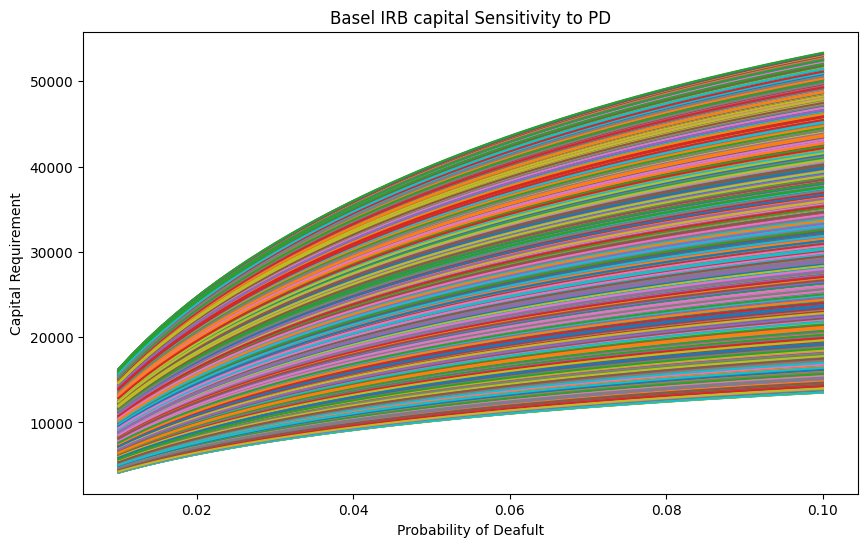

In [10]:
pd_range = np.linspace(0.01,0.10,50)
capital_values=[]

for pd_val in pd_range:
    z_pd = norm.ppf(pd_val)
    z_conf = norm.ppf(0.999)

    k = LGD * norm.cdf((z_pd + np.sqrt(rho)* z_conf)/ np.sqrt(1-rho)) - pd_val*LGD
    capital_values.append(k*EAD)

plt.figure(figsize = (10,6))
plt.plot(pd_range, capital_values)
plt.xlabel("Probability of Deafult")
plt.ylabel("Capital Requirement")
plt.title("Basel IRB capital Sensitivity to PD")
plt.show()

In [11]:
#capital and Correlation

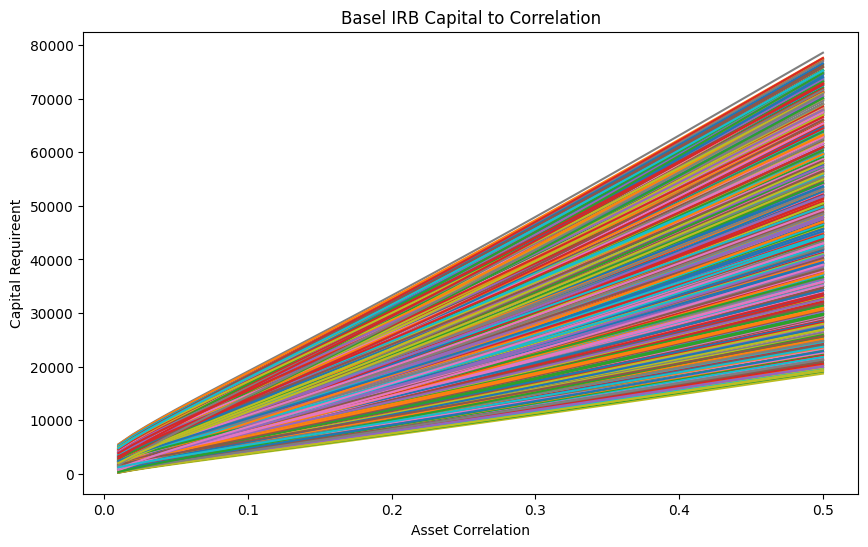

In [12]:
rho_range = np.linspace(0.01,0.5, 50)
capital_corr = []

for rho_val in rho_range:
    z_pd = norm.ppf(PD.mean())
    z_conf = norm.ppf(0.999)
    k = LGD * norm.cdf(( z_pd + np.sqrt(rho_val) * z_conf) / np.sqrt(1-rho_val) ) - PD*LGD
    capital_corr.append(k*EAD)

plt.figure(figsize=(10,6))
plt.plot(rho_range, capital_corr)
plt.xlabel("Asset Correlation")
plt.ylabel("Capital Requireent")
plt.title("Basel IRB Capital to Correlation")
plt.show()